In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [4]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [5]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [6]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [7]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [8]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100], # control misclassification penalty
    'gamma': [0.001, 0.01, 0.1, 1], # control training points influence
    'kernel': ['rbf', 'poly']
}

In [9]:
# Create SVM classifier
svm = SVC(random_state=42)

In [10]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [11]:
# Start timing
start_time = time.time()


In [12]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf', 'poly']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,100


In [13]:
# End timing
grid_time = time.time() - start_time

In [14]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 5.84 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [15]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [16]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

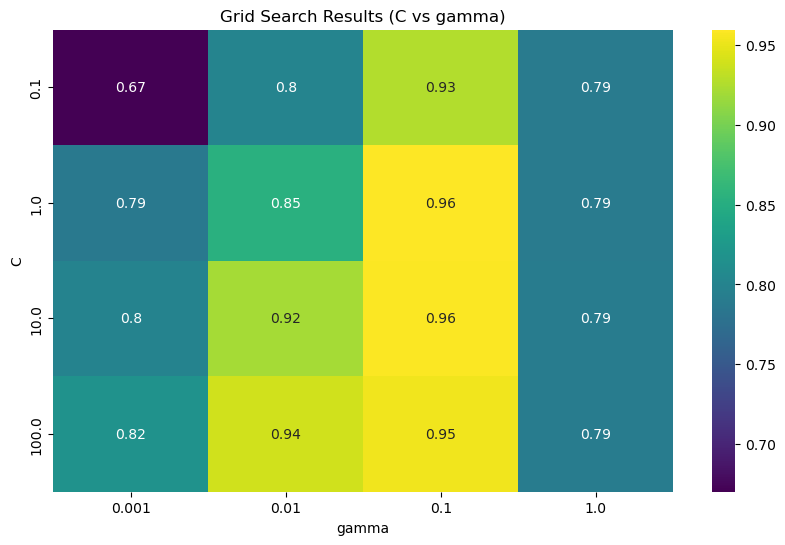

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [18]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [19]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [20]:
# Start timing
start_time = time.time()

In [21]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,param_distributions,"{'C': <scipy.stats....002277B10D7E0>, 'gamma': <scipy.stats....0022720181090>, 'kernel': ['rbf', 'poly']}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
# End timing
random_time = time.time() - start_time

In [23]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 0.27 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [24]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [25]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            5.836268
1  Random Search       0.971429       0.964912            0.265693


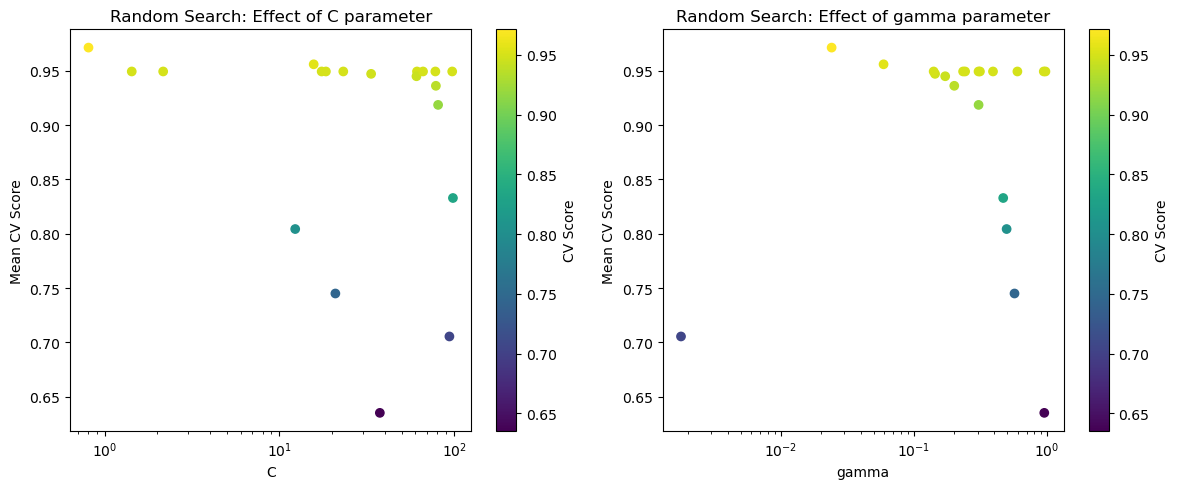

In [26]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [27]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

In [28]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [29]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [30]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [31]:
# Start timing
start_time = time.time()

In [32]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,search_spaces,"{'C': Real(low=0.1,...m='normalize'), 'gamma': Real(low=0.00...m='normalize'), 'kernel': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,20
,scoring,'accuracy'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [33]:
# End timing
bayes_time = time.time() - start_time

In [34]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 8.31 seconds
Best parameters: OrderedDict([('C', 47.479208101335), ('gamma', 0.015041969444180596), ('kernel', 'rbf')])
Best cross-validation score: 0.9626


In [35]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [36]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            5.836268
1          Random Search       0.971429       0.964912            0.265693
2  Bayesian Optimization       0.962637       0.956140            8.312367


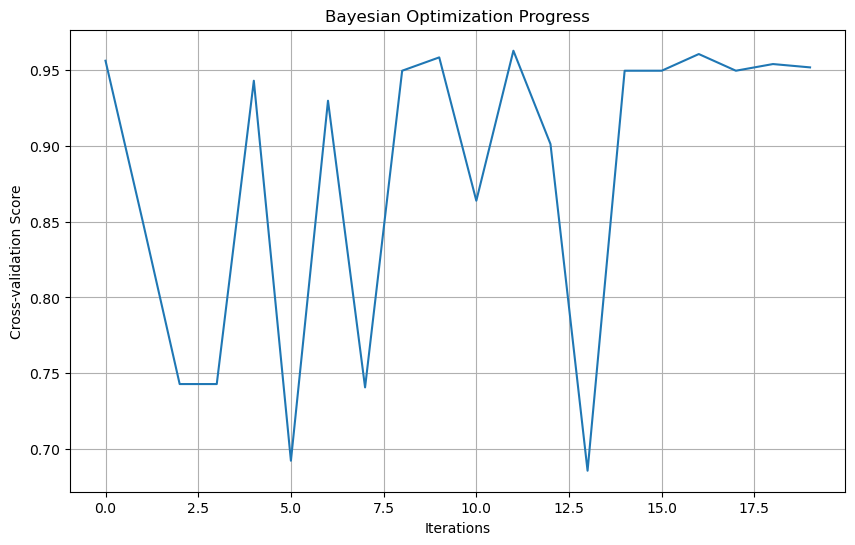

In [37]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [38]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [39]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [40]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [41]:
# Start timing
start_time = time.time()

In [42]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\pipeline.py", line

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'regressor__max_depth': <scipy.stats....002272005AE30>, 'regressor__max_features': ['auto', 'sqrt', ...], 'regressor__min_samples_leaf': <scipy.stats....002272005A770>, 'regressor__min_samples_split': <scipy.stats....00227200596C0>, ...}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [43]:
# End timing
rf_random_time = time.time() - start_time

In [44]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 2.29 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [45]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [46]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

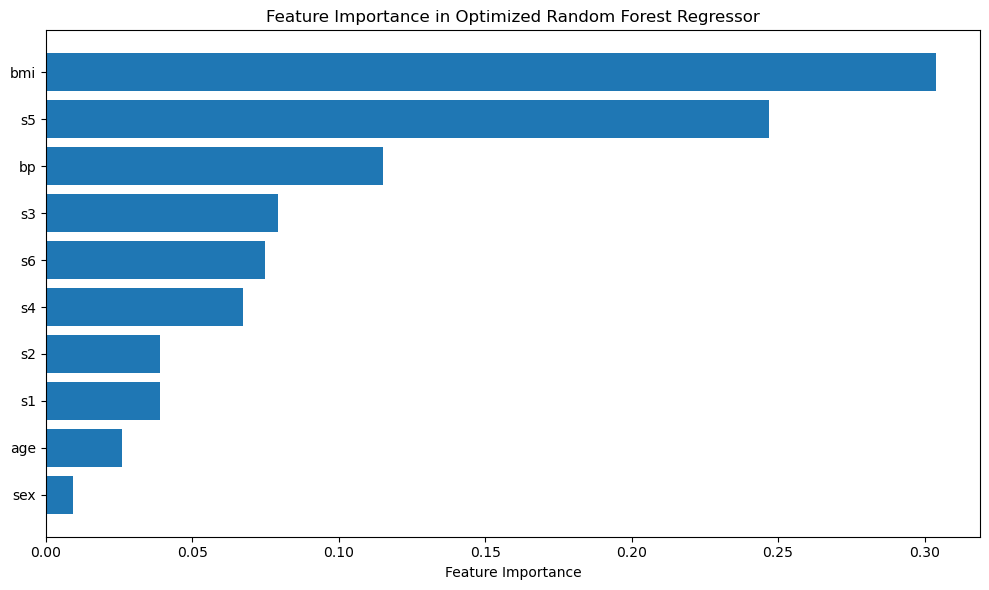

In [47]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [48]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [49]:
from sklearn.model_selection import learning_curve


In [50]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

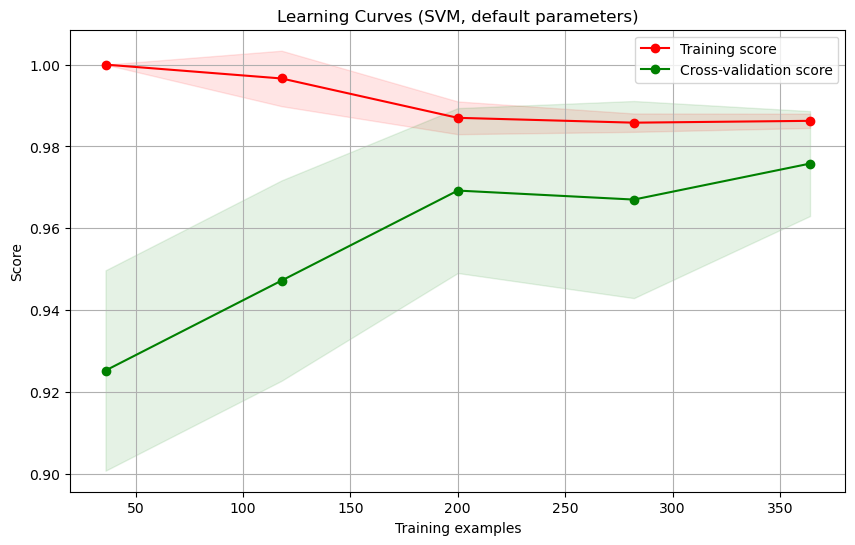

In [51]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

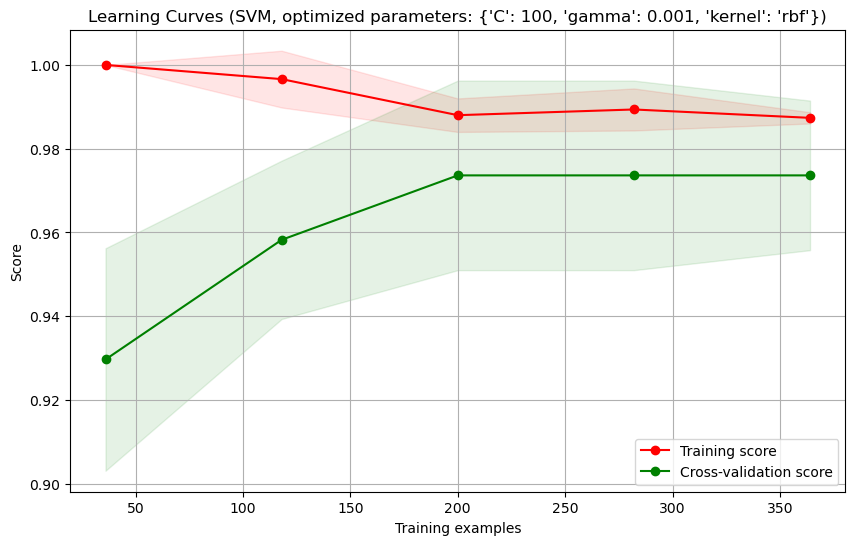

In [52]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [53]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

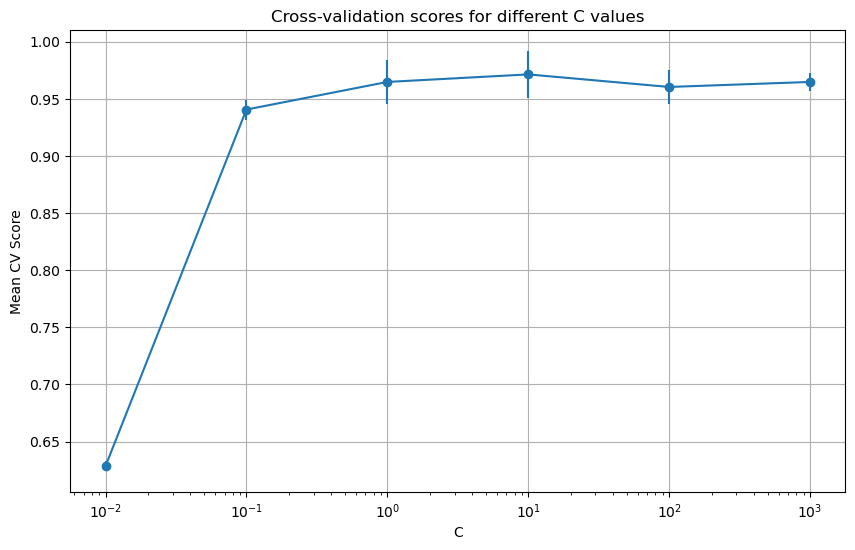

In [54]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

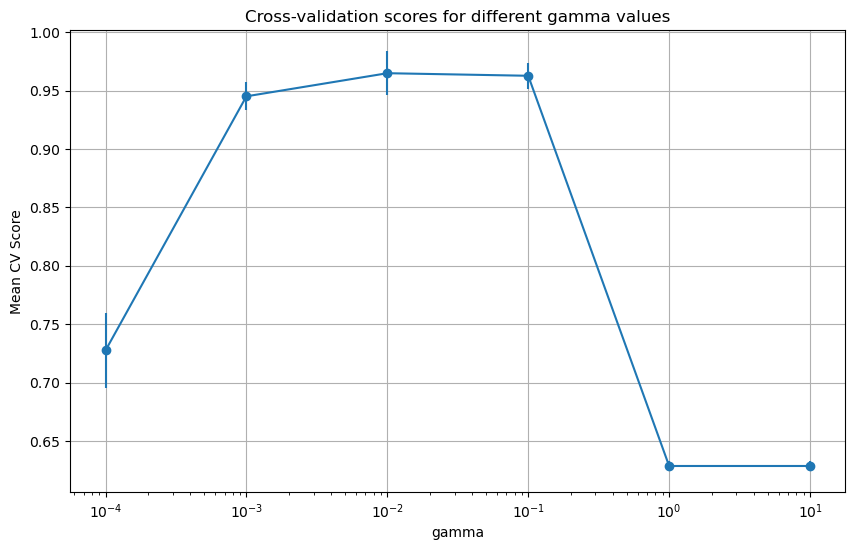

In [55]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [56]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [57]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [58]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [59]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [60]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [61]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,param_distributions,"{'C': <scipy.stats....00227209A4550>, 'gamma': <scipy.stats....0022721000430>, 'kernel': ['rbf']}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [62]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [63]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [64]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [65]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [66]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            5.836268
1          Random Search       0.971429       0.964912            0.265693
2  Bayesian Optimization       0.962637       0.956140            8.312367
3      Combined Approach       0.978022       0.982456                 NaN


C:\Users\ZEENAT MUSTAFA\AppData\Local\Temp\ipykernel_11528\3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [68]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

,C,47.479208101335
,kernel,'rbf'
,degree,3
,gamma,0.015041969444180596
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [69]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [70]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

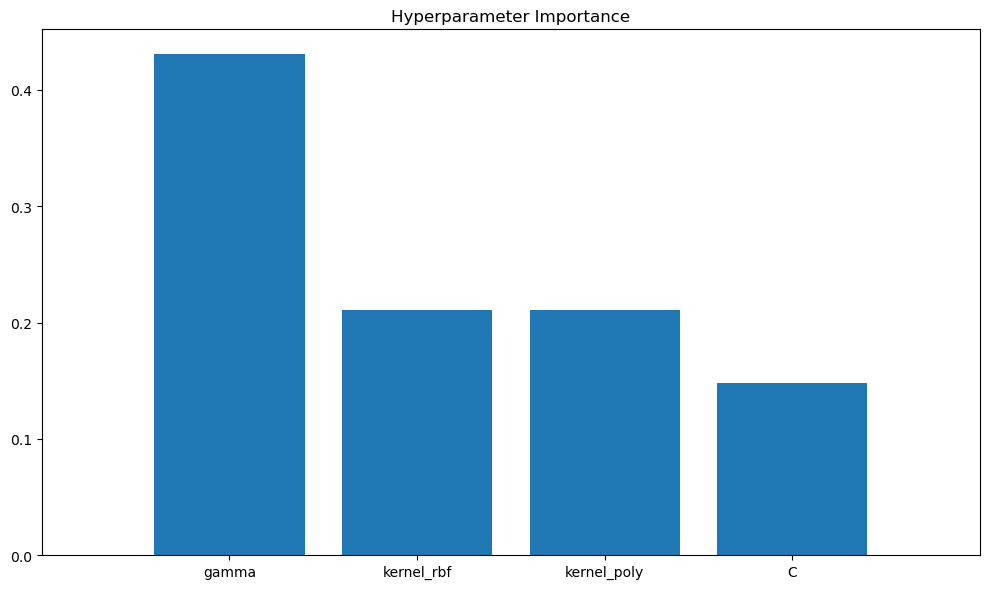

In [72]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [73]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

C:\Users\ZEENAT MUSTAFA\AppData\Local\Temp\ipykernel_11528\149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


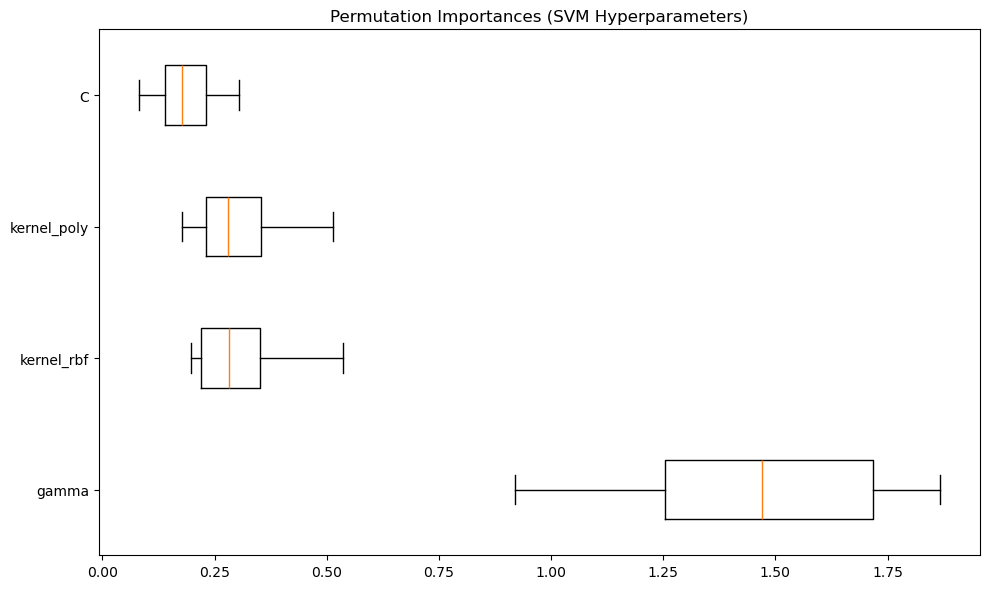

In [74]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [75]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [81]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TODO: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Ridge Regression:
  RMSE: 0.7205 (+/- 0.0103)
  R²:   0.6115 (+/- 0.0065)

SVR:
  RMSE: 0.5931 (+/- 0.0106)
  R²:   0.7368 (+/- 0.0048)

Random Forest:
  RMSE: 0.5114 (+/- 0.0044)
  R²:   0.8042 (+/- 0.0053)

Gradient Boosting:
  RMSE: 0.5340 (+/- 0.0071)
  R²:   0.7866 (+/- 0.0032)

               Model  RMSE Mean  RMSE Std   R2 Mean    R2 Std   Time (s)
0   Ridge Regression   0.720527  0.010280  0.611484  0.006460   0.043114
1                SVR   0.593056  0.010570  0.736814  0.004814  51.473615
2      Random Forest   0.511423  0.004391  0.804195  0.005342  72.481342
3  Gradient Boosting   0.534012  0.007127  0.786592  0.003211  24.255322


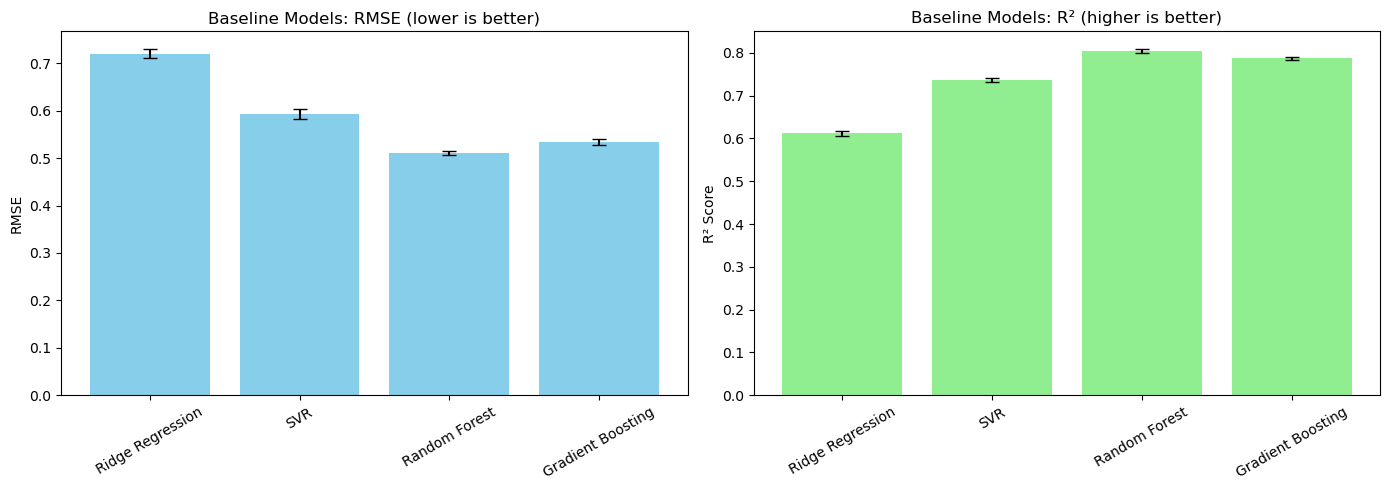

In [82]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
baseline_models = {
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# TODO: Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model
baseline_results = []

for name, model in baseline_models.items():
    start_time = time.time()
    
    # Cross-validated RMSE (sklearn returns neg MSE, so flip sign then sqrt)
    neg_mse_scores = cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-neg_mse_scores)
    
    # Cross-validated R²
    r2_scores = cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring='r2'
    )
    
    elapsed = time.time() - start_time
    
    baseline_results.append({
        'Model': name,
        'RMSE Mean': rmse_scores.mean(),
        'RMSE Std': rmse_scores.std(),
        'R2 Mean': r2_scores.mean(),
        'R2 Std': r2_scores.std(),
        'Time (s)': elapsed
    })
    
    print(f"{name}:")
    print(f"  RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")
    print(f"  R²:   {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
    print()

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df)

# TODO: Visualize baseline model performance with a bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE plot (lower is better)
axes[0].bar(baseline_df['Model'], baseline_df['RMSE Mean'], 
            yerr=baseline_df['RMSE Std'], capsize=5, color='skyblue')
axes[0].set_title('Baseline Models: RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

# R² plot (higher is better)
axes[1].bar(baseline_df['Model'], baseline_df['R2 Mean'], 
            yerr=baseline_df['R2 Std'], capsize=5, color='lightgreen')
axes[1].set_title('Baseline Models: R² (higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

--- Starting Grid Search: Ridge Regression ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
--- Finished Ridge Regression in 6.83s ---

[Ridge Regression] Best params: {'alpha': 0.1}
[Ridge Regression] Best RMSE (CV): 0.7206
[Ridge Regression] Time: 6.83s

--- Starting Grid Search: SVR ---
Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=20000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


--- Finished SVR in 165.23s ---

[SVR] Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
[SVR] Best RMSE (CV): 0.5738
[SVR] Time: 165.23s

--- Starting Grid Search: Random Forest ---
Fitting 5 folds for each of 240 candidates, totalling 1200 fits
--- Finished Random Forest in 954.06s ---

[Random Forest] Best params: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
[Random Forest] Best RMSE (CV): 0.5095
[Random Forest] Time: 954.06s

--- Starting Grid Search: Gradient Boosting ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
--- Finished Gradient Boosting in 92.38s ---

[Gradient Boosting] Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
[Gradient Boosting] Best RMSE (CV): 0.4689
[Gradient Boosting] Time: 92.38s

               Model  Best RMSE (CV)    Time (s)  \
0   Ridge Regression        0.720601    6.825841   
1                SVR        0.573806  165.229382   
2      Random Forest        0.509511  954.

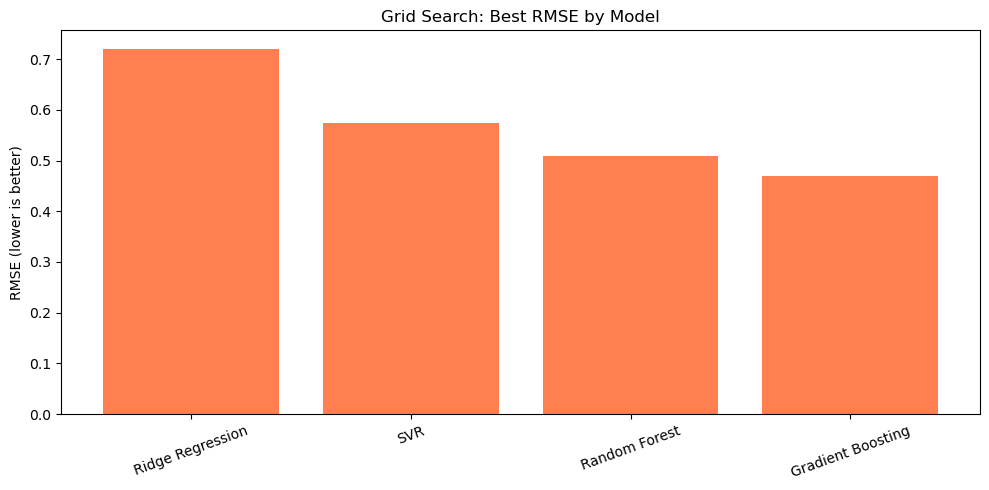

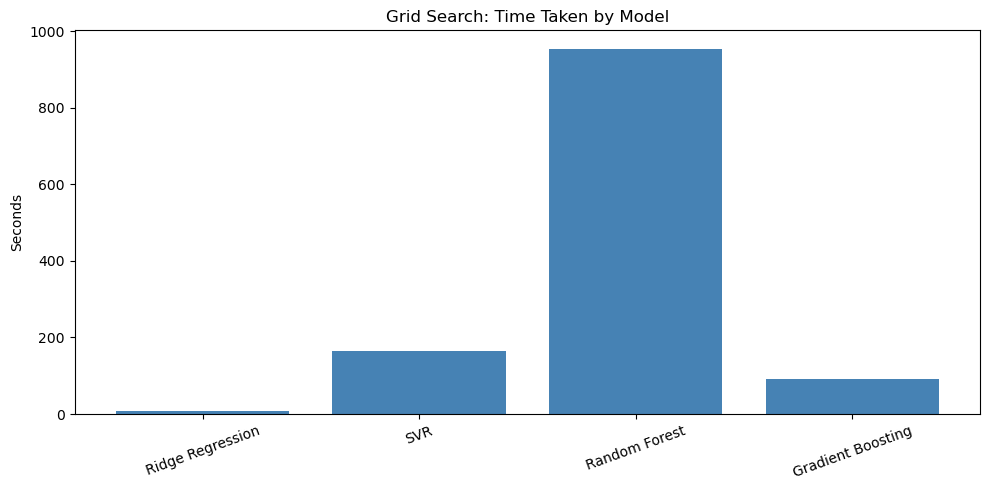

In [84]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

# TODO: Define parameter grids for each model
param_grids = {
    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    'SVR': {
        'C': [0.1, 1, 10, 100, 1000],
        'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf']   # dropped 'linear' — was hanging on ~16.5k rows
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [5, 10, 20, 30, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2]
    }
}

# Models to tune (fresh instances, n_jobs left at default to avoid oversubscription)
models_to_tune = {
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(max_iter=20000),   # capped so no combo can hang indefinitely
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# TODO: Create a function that performs grid search for a given model and parameter grid
def run_grid_search(model, param_grid, X_train, y_train, model_name=""):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        verbose=2,          # live progress: shows each fold + fit timing
        scoring='neg_mean_squared_error'
    )
    print(f"--- Starting Grid Search: {model_name} ---")
    start_time = time.time()
    grid.fit(X_train, y_train)
    elapsed = time.time() - start_time
    print(f"--- Finished {model_name} in {elapsed:.2f}s ---\n")
    
    return grid.best_estimator_, grid.best_params_, grid.best_score_, elapsed

# TODO: Apply grid search to all models
grid_search_results = {}

for name, model in models_to_tune.items():
    best_model, best_params, best_score, elapsed = run_grid_search(
        model, param_grids[name], X_train_scaled, y_train, model_name=name
    )
    
    grid_search_results[name] = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,       # neg MSE
        'rmse': np.sqrt(-best_score),
        'time': elapsed
    }
    
    print(f"[{name}] Best params: {best_params}")
    print(f"[{name}] Best RMSE (CV): {np.sqrt(-best_score):.4f}")
    print(f"[{name}] Time: {elapsed:.2f}s\n")

# TODO: Create a comparison table or visualization of grid search results
grid_comparison = pd.DataFrame([
    {
        'Model': name,
        'Best RMSE (CV)': res['rmse'],
        'Time (s)': res['time'],
        'Best Params': res['best_params']
    }
    for name, res in grid_search_results.items()
])
print(grid_comparison)

plt.figure(figsize=(10, 5))
plt.bar(grid_comparison['Model'], grid_comparison['Best RMSE (CV)'], color='coral')
plt.title('Grid Search: Best RMSE by Model')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(grid_comparison['Model'], grid_comparison['Time (s)'], color='steelblue')
plt.title('Grid Search: Time Taken by Model')
plt.ylabel('Seconds')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

--- Starting Random Search: Ridge Regression ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
--- Finished Ridge Regression in 0.27s ---

[Ridge Regression] Best params: {'alpha': np.float64(20.585494295802448)}
[Ridge Regression] Best RMSE (CV): 0.7206
[Ridge Regression] Time: 0.27s

--- Starting Random Search: SVR ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=20000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


--- Finished SVR in 123.50s ---

[SVR] Best params: {'C': np.float64(20.68449429580245), 'gamma': np.float64(0.9700098521619943)}
[SVR] Best RMSE (CV): 0.5916
[SVR] Time: 123.50s

--- Starting Random Search: Random Forest ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
--- Finished Random Forest in 126.10s ---

[Random Forest] Best params: {'max_depth': 23, 'min_samples_split': 2, 'n_estimators': 253}
[Random Forest] Best RMSE (CV): 0.5098
[Random Forest] Time: 126.10s

--- Starting Random Search: Gradient Boosting ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
--- Finished Gradient Boosting in 47.56s ---

[Gradient Boosting] Best params: {'learning_rate': np.float64(0.061755996320003385), 'max_depth': 6, 'n_estimators': 181}
[Gradient Boosting] Best RMSE (CV): 0.4783
[Gradient Boosting] Time: 47.56s

               Model  Best RMSE (CV)    Time (s)  \
0   Ridge Regression        0.720641    0.273009   
1                SVR        0.591649  123.5032

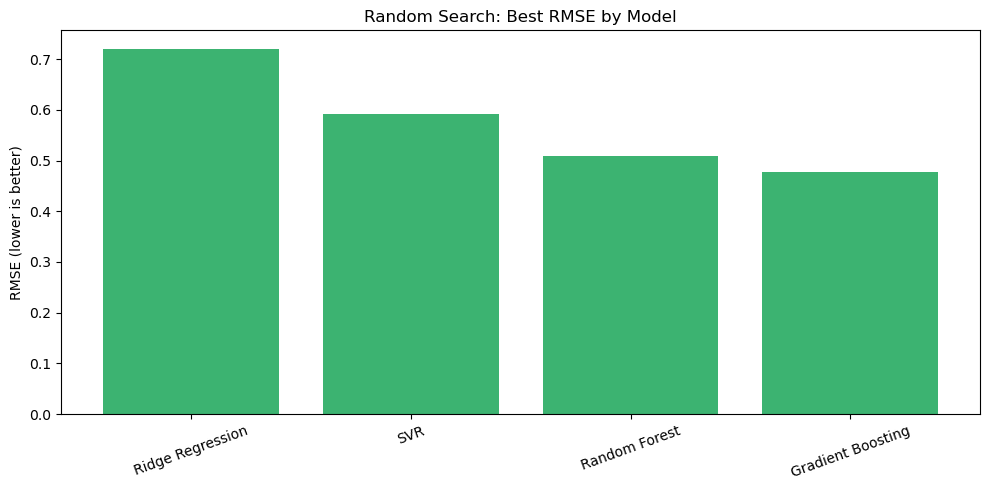

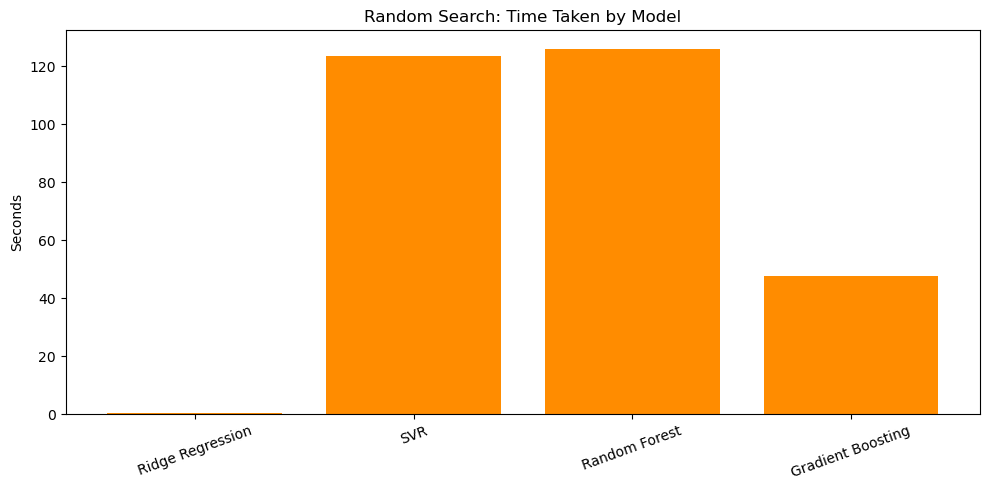

In [85]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
param_distributions = {
    'Ridge Regression': {
        'alpha': uniform(0.001, 1000)
    },
    'SVR': {
        'C': uniform(0.1, 1000),
        'gamma': uniform(0.0001, 1)
    },
    'Random Forest': {
        'n_estimators': randint(50, 300),
        'max_depth': randint(3, 30),
        'min_samples_split': randint(2, 15)
    },
    'Gradient Boosting': {
        'n_estimators': randint(50, 200),
        'max_depth': randint(3, 7),
        'learning_rate': uniform(0.01, 0.2)
    }
}

# Fresh model instances
models_to_tune_random = {
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(max_iter=20000),   # same safety cap as Part 3
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# TODO: Create a function that performs random search for a given model and parameter distribution
def run_random_search(model, param_dist, X_train, y_train, model_name="", n_iter=20):
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=5,
        n_jobs=-1,
        verbose=1,          # summary per fold batch, not every single fit
        random_state=42,
        scoring='neg_mean_squared_error'
    )
    print(f"--- Starting Random Search: {model_name} ---")
    start_time = time.time()
    random_search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    print(f"--- Finished {model_name} in {elapsed:.2f}s ---\n")
    
    return random_search.best_estimator_, random_search.best_params_, random_search.best_score_, elapsed

# TODO: Apply random search to all models with 20 iterations
random_search_results = {}

for name, model in models_to_tune_random.items():
    best_model, best_params, best_score, elapsed = run_random_search(
        model, param_distributions[name], X_train_scaled, y_train, model_name=name, n_iter=20
    )
    
    random_search_results[name] = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'rmse': np.sqrt(-best_score),
        'time': elapsed
    }
    
    print(f"[{name}] Best params: {best_params}")
    print(f"[{name}] Best RMSE (CV): {np.sqrt(-best_score):.4f}")
    print(f"[{name}] Time: {elapsed:.2f}s\n")

# TODO: Create a comparison table or visualization of random search results
random_comparison = pd.DataFrame([
    {
        'Model': name,
        'Best RMSE (CV)': res['rmse'],
        'Time (s)': res['time'],
        'Best Params': res['best_params']
    }
    for name, res in random_search_results.items()
])
print(random_comparison)

plt.figure(figsize=(10, 5))
plt.bar(random_comparison['Model'], random_comparison['Best RMSE (CV)'], color='mediumseagreen')
plt.title('Random Search: Best RMSE by Model')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(random_comparison['Model'], random_comparison['Time (s)'], color='darkorange')
plt.title('Random Search: Time Taken by Model')
plt.ylabel('Seconds')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

--- Starting Bayesian Optimization: Ridge Regression ---
--- Finished Ridge Regression in 21.53s ---

[Ridge Regression] Best params: OrderedDict([('alpha', 0.11309259859202354)])
[Ridge Regression] Best RMSE (CV): 0.7206
[Ridge Regression] Time: 21.53s

--- Starting Bayesian Optimization: SVR ---


c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=20000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


--- Finished SVR in 150.44s ---

[SVR] Best params: OrderedDict([('C', 6.016307829589929), ('gamma', 0.47303152673203885)])
[SVR] Best RMSE (CV): 0.5550
[SVR] Time: 150.44s

--- Starting Bayesian Optimization: Random Forest ---
--- Finished Random Forest in 285.31s ---

[Random Forest] Best params: OrderedDict([('max_depth', 27), ('min_samples_split', 2), ('n_estimators', 299)])
[Random Forest] Best RMSE (CV): 0.5097
[Random Forest] Time: 285.31s

--- Starting Bayesian Optimization: Gradient Boosting ---
--- Finished Gradient Boosting in 162.21s ---

[Gradient Boosting] Best params: OrderedDict([('learning_rate', 0.08932910651525923), ('max_depth', 7), ('n_estimators', 200)])
[Gradient Boosting] Best RMSE (CV): 0.4679
[Gradient Boosting] Time: 162.21s

               Model  Best RMSE (CV)    Time (s)  \
0   Ridge Regression        0.720601   21.525602   
1                SVR        0.555042  150.443288   
2      Random Forest        0.509683  285.310793   
3  Gradient Boosting        0

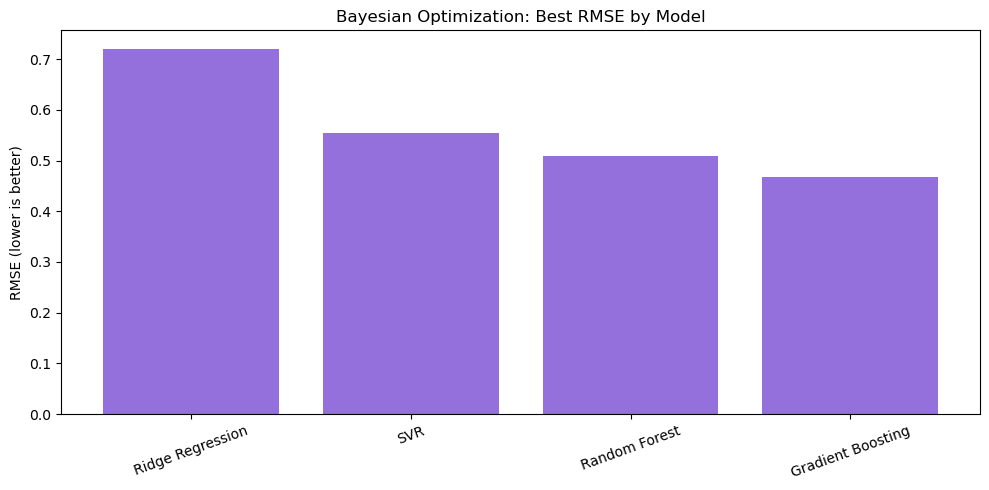

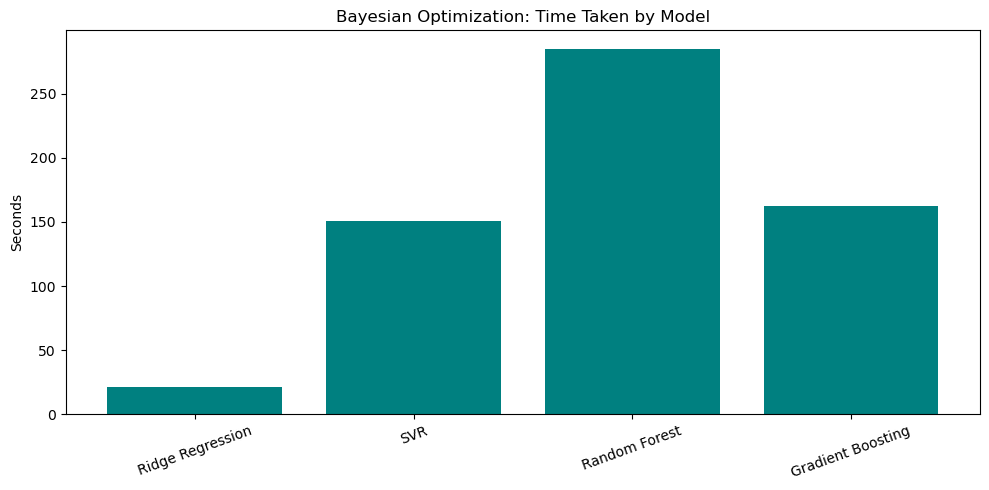

In [86]:
# ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
!pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
search_spaces = {
    'Ridge Regression': {
        'alpha': Real(0.001, 1000, prior='log-uniform')
    },
    'SVR': {
        'C': Real(0.1, 1000, prior='log-uniform'),
        'gamma': Real(0.0001, 1, prior='log-uniform')
    },
    'Random Forest': {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(3, 30),
        'min_samples_split': Integer(2, 15)
    },
    'Gradient Boosting': {
        'n_estimators': Integer(50, 200),
        'max_depth': Integer(3, 7),
        'learning_rate': Real(0.01, 0.2, prior='log-uniform')
    }
}

# Fresh model instances
models_to_tune_bayes = {
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(max_iter=20000),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# TODO: Create a function that performs Bayesian optimization for a given model and search space
def run_bayes_search(model, search_space, X_train, y_train, model_name="", n_iter=20):
    bayes_search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=5,
        n_jobs=-1,
        verbose=0,
        random_state=42,
        scoring='neg_mean_squared_error'
    )
    print(f"--- Starting Bayesian Optimization: {model_name} ---")
    start_time = time.time()
    bayes_search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    print(f"--- Finished {model_name} in {elapsed:.2f}s ---\n")
    
    return bayes_search.best_estimator_, bayes_search.best_params_, bayes_search.best_score_, elapsed

# TODO: Apply Bayesian optimization to all models with 20 iterations
bayes_search_results = {}

for name, model in models_to_tune_bayes.items():
    best_model, best_params, best_score, elapsed = run_bayes_search(
        model, search_spaces[name], X_train_scaled, y_train, model_name=name, n_iter=20
    )
    
    bayes_search_results[name] = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'rmse': np.sqrt(-best_score),
        'time': elapsed
    }
    
    print(f"[{name}] Best params: {best_params}")
    print(f"[{name}] Best RMSE (CV): {np.sqrt(-best_score):.4f}")
    print(f"[{name}] Time: {elapsed:.2f}s\n")

# TODO: Create a comparison table or visualization of Bayesian optimization results
bayes_comparison = pd.DataFrame([
    {
        'Model': name,
        'Best RMSE (CV)': res['rmse'],
        'Time (s)': res['time'],
        'Best Params': res['best_params']
    }
    for name, res in bayes_search_results.items()
])
print(bayes_comparison)

plt.figure(figsize=(10, 5))
plt.bar(bayes_comparison['Model'], bayes_comparison['Best RMSE (CV)'], color='mediumpurple')
plt.title('Bayesian Optimization: Best RMSE by Model')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(bayes_comparison['Model'], bayes_comparison['Time (s)'], color='teal')
plt.title('Bayesian Optimization: Time Taken by Model')
plt.ylabel('Seconds')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

            Model                Method  Baseline RMSE  Tuned RMSE  Improvement (%)   Time (s)
 Ridge Regression           Grid Search       0.720527    0.720601        -0.010166   6.825841
 Ridge Regression         Random Search       0.720527    0.720641        -0.015750   0.273009
 Ridge Regression Bayesian Optimization       0.720527    0.720601        -0.010166  21.525602
              SVR           Grid Search       0.593056    0.573806         3.245891 165.229382
              SVR         Random Search       0.593056    0.591649         0.237315 123.503238
              SVR Bayesian Optimization       0.593056    0.555042         6.409912 150.443288
    Random Forest           Grid Search       0.511423    0.509511         0.373771 954.057958
    Random Forest         Random Search       0.511423    0.509775         0.322229 126.098706
    Random Forest Bayesian Optimization       0.511423    0.509683         0.340157 285.310793
Gradient Boosting           Grid Search       0.53

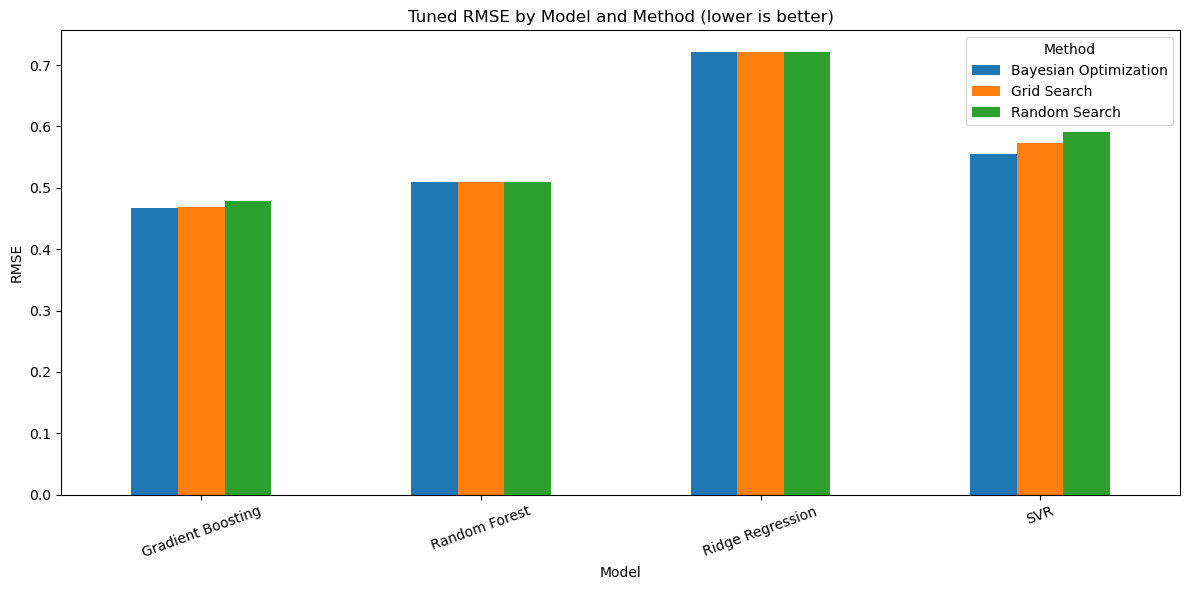

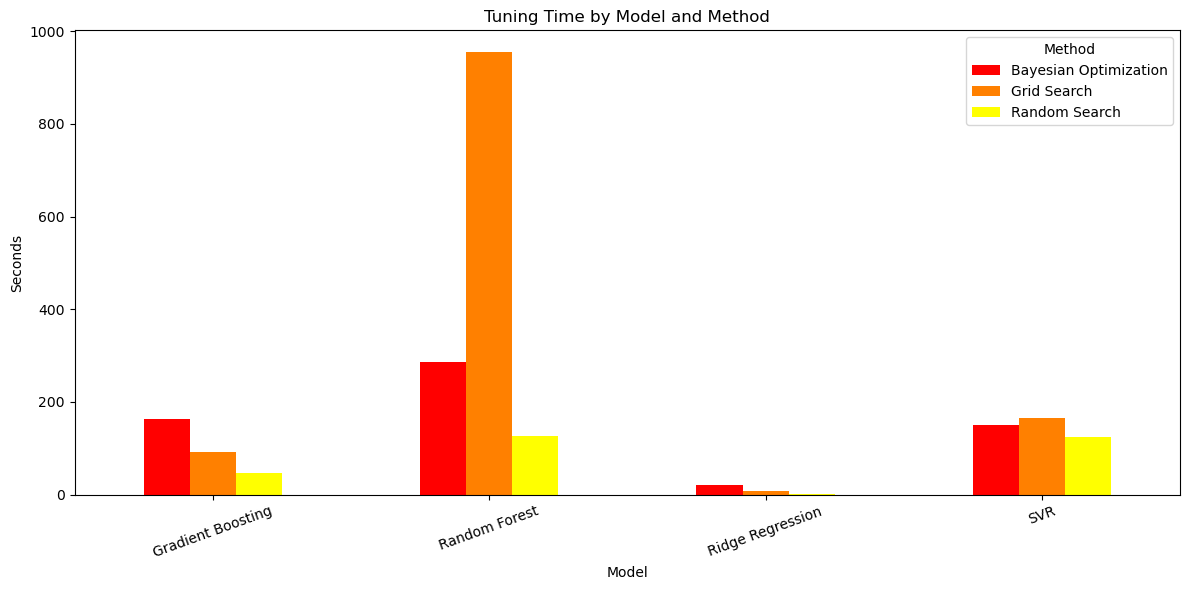

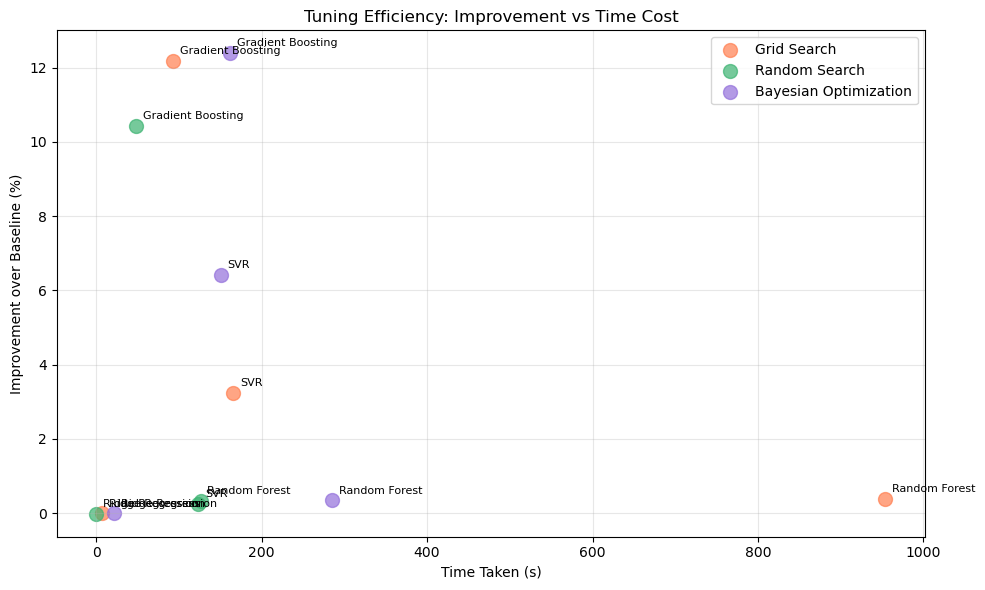

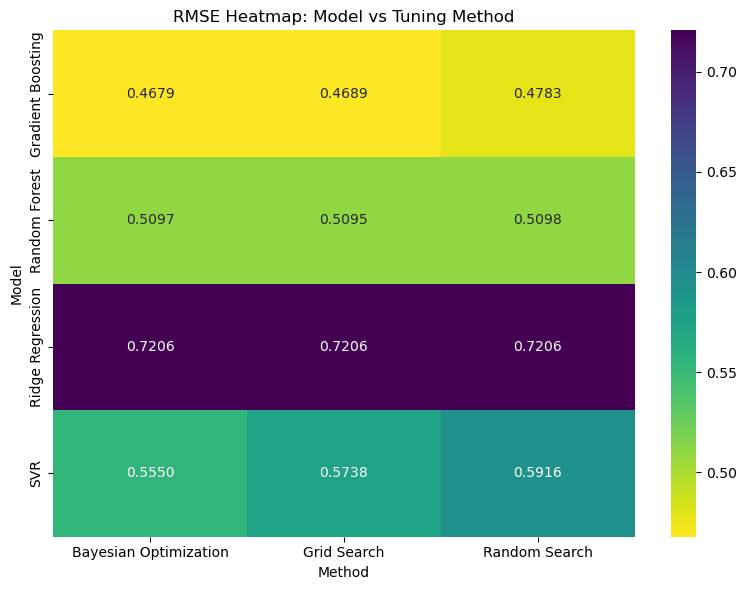

In [87]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline

comparison_rows = []

model_names = ['Ridge Regression', 'SVR', 'Random Forest', 'Gradient Boosting']
method_results = {
    'Grid Search': grid_search_results,
    'Random Search': random_search_results,
    'Bayesian Optimization': bayes_search_results
}

for model_name in model_names:
    baseline_rmse = baseline_df.loc[baseline_df['Model'] == model_name, 'RMSE Mean'].values[0]
    
    for method_name, results_dict in method_results.items():
        tuned_rmse = results_dict[model_name]['rmse']
        tuned_time = results_dict[model_name]['time']
        improvement_pct = ((baseline_rmse - tuned_rmse) / baseline_rmse) * 100
        
        comparison_rows.append({
            'Model': model_name,
            'Method': method_name,
            'Baseline RMSE': baseline_rmse,
            'Tuned RMSE': tuned_rmse,
            'Improvement (%)': improvement_pct,
            'Time (s)': tuned_time
        })

full_comparison = pd.DataFrame(comparison_rows)
print(full_comparison.to_string(index=False))

# Best method per model (lowest tuned RMSE)
print("\nBest tuning method per model:")
best_per_model = full_comparison.loc[full_comparison.groupby('Model')['Tuned RMSE'].idxmin()]
print(best_per_model[['Model', 'Method', 'Tuned RMSE', 'Improvement (%)']].to_string(index=False))

# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps

# 1. Grouped bar plot: RMSE by model and method
pivot_rmse = full_comparison.pivot(index='Model', columns='Method', values='Tuned RMSE')
pivot_rmse.plot(kind='bar', figsize=(12, 6))
plt.title('Tuned RMSE by Model and Method (lower is better)')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.legend(title='Method')
plt.tight_layout()
plt.show()

# 2. Grouped bar plot: Time by model and method
pivot_time = full_comparison.pivot(index='Model', columns='Method', values='Time (s)')
pivot_time.plot(kind='bar', figsize=(12, 6), colormap='autumn')
plt.title('Tuning Time by Model and Method')
plt.ylabel('Seconds')
plt.xticks(rotation=20)
plt.legend(title='Method')
plt.tight_layout()
plt.show()

# 3. Scatter plot: Time vs Improvement (efficiency at a glance)
plt.figure(figsize=(10, 6))
colors = {'Grid Search': 'coral', 'Random Search': 'mediumseagreen', 'Bayesian Optimization': 'mediumpurple'}
for method in method_results.keys():
    subset = full_comparison[full_comparison['Method'] == method]
    plt.scatter(subset['Time (s)'], subset['Improvement (%)'], 
                label=method, color=colors[method], s=100, alpha=0.7)
    for _, row in subset.iterrows():
        plt.annotate(row['Model'], (row['Time (s)'], row['Improvement (%)']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')
plt.xlabel('Time Taken (s)')
plt.ylabel('Improvement over Baseline (%)')
plt.title('Tuning Efficiency: Improvement vs Time Cost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Heatmap: RMSE across model/method combos
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_rmse, annot=True, fmt='.4f', cmap='viridis_r')
plt.title('RMSE Heatmap: Model vs Tuning Method')
plt.tight_layout()
plt.show()

            Model                Method  Improvement (%)   Time (s)  Efficiency
 Ridge Regression           Grid Search        -0.010166   6.825841   -0.001489
 Ridge Regression         Random Search        -0.015750   0.273009   -0.057691
 Ridge Regression Bayesian Optimization        -0.010166  21.525602   -0.000472
              SVR           Grid Search         3.245891 165.229382    0.019645
              SVR         Random Search         0.237315 123.503238    0.001922
              SVR Bayesian Optimization         6.409912 150.443288    0.042607
    Random Forest           Grid Search         0.373771 954.057958    0.000392
    Random Forest         Random Search         0.322229 126.098706    0.002555
    Random Forest Bayesian Optimization         0.340157 285.310793    0.001192
Gradient Boosting           Grid Search        12.185056  92.382091    0.131898
Gradient Boosting         Random Search        10.426567  47.557897    0.219239
Gradient Boosting Bayesian Optimization 

<Figure size 1000x600 with 0 Axes>

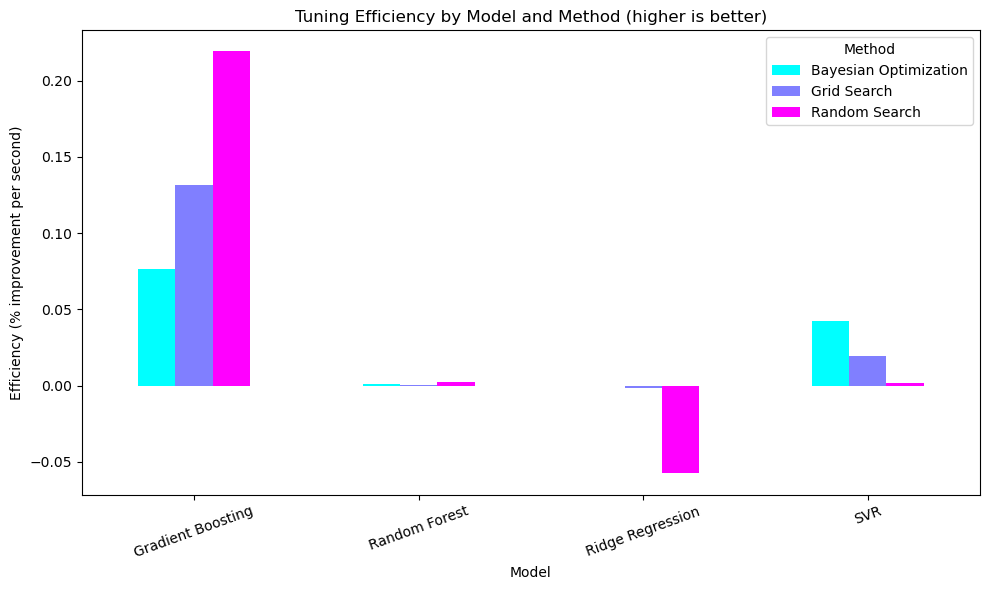

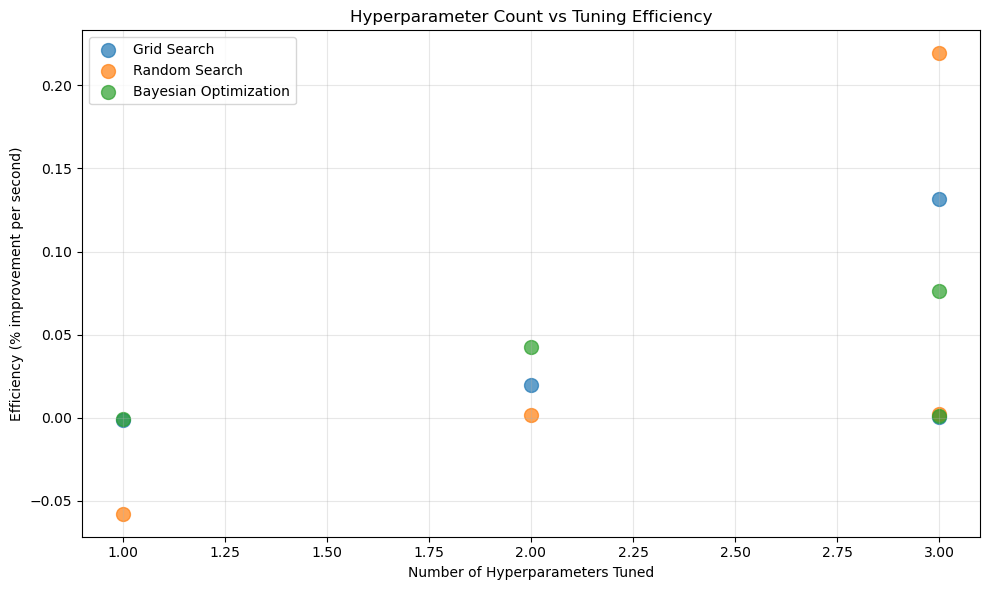

Correlation between number of hyperparameters and efficiency: 0.5389
Sample 1/30: size=302, best_algorithm=Gradient Boosting
Sample 2/30: size=782, best_algorithm=Gradient Boosting
Sample 3/30: size=496, best_algorithm=Gradient Boosting
Sample 4/30: size=956, best_algorithm=Gradient Boosting
Sample 5/30: size=669, best_algorithm=Gradient Boosting
Sample 6/30: size=867, best_algorithm=Gradient Boosting
Sample 7/30: size=412, best_algorithm=Gradient Boosting
Sample 8/30: size=387, best_algorithm=Gradient Boosting
Sample 9/30: size=675, best_algorithm=Gradient Boosting
Sample 10/30: size=616, best_algorithm=Gradient Boosting
Sample 11/30: size=290, best_algorithm=Gradient Boosting
Sample 12/30: size=391, best_algorithm=Gradient Boosting
Sample 13/30: size=944, best_algorithm=Gradient Boosting
Sample 14/30: size=362, best_algorithm=Random Forest
Sample 15/30: size=347, best_algorithm=Gradient Boosting
Sample 16/30: size=685, best_algorithm=Gradient Boosting
Sample 17/30: size=979, best_alg

c:\Users\ZEENAT MUSTAFA\.conda\envs\ai-bootcamp\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Meta-classifier CV accuracy: 0.9000 (+/- 0.0816)

Which dataset characteristics matter most for predicting the best algorithm:
            Feature  Importance
6  feature_skew_avg    0.194037
2       target_mean    0.174739
4  feature_mean_avg    0.168934
5   feature_std_avg    0.145426
0       n_instances    0.127448
3        target_std    0.101207
7      target_range    0.088208
1        n_features    0.000000


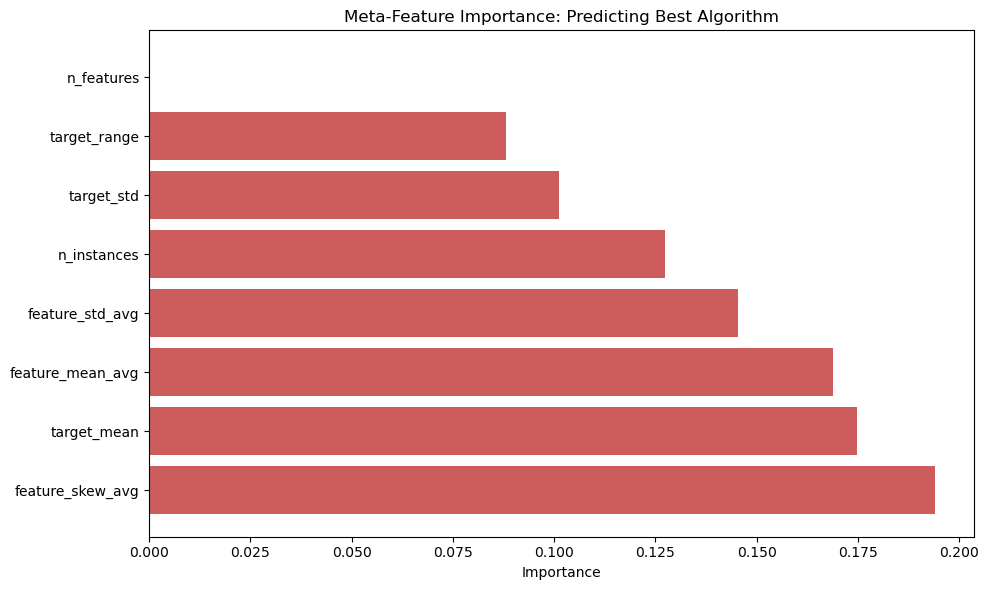

In [88]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
full_comparison['Efficiency'] = full_comparison['Improvement (%)'] / full_comparison['Time (s)']
print(full_comparison[['Model', 'Method', 'Improvement (%)', 'Time (s)', 'Efficiency']].to_string(index=False))

plt.figure(figsize=(10, 6))
pivot_eff = full_comparison.pivot(index='Model', columns='Method', values='Efficiency')
pivot_eff.plot(kind='bar', figsize=(10, 6), colormap='cool')
plt.title('Tuning Efficiency by Model and Method (higher is better)')
plt.ylabel('Efficiency (% improvement per second)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
num_hyperparams = {
    'Ridge Regression': 1,   # alpha
    'SVR': 2,                # C, gamma
    'Random Forest': 3,      # n_estimators, max_depth, min_samples_split
    'Gradient Boosting': 3   # n_estimators, max_depth, learning_rate
}
full_comparison['Num Hyperparams'] = full_comparison['Model'].map(num_hyperparams)

plt.figure(figsize=(10, 6))
for method in method_results.keys():
    subset = full_comparison[full_comparison['Method'] == method]
    plt.scatter(subset['Num Hyperparams'], subset['Efficiency'], label=method, s=100, alpha=0.7)
plt.xlabel('Number of Hyperparameters Tuned')
plt.ylabel('Efficiency (% improvement per second)')
plt.title('Hyperparameter Count vs Tuning Efficiency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = full_comparison[['Num Hyperparams', 'Efficiency']].corr().iloc[0, 1]
print(f"Correlation between number of hyperparameters and efficiency: {corr:.4f}")

# ==============================================================================
# Meta-learning: Predict which algorithm performs best based on a subset of data
# ==============================================================================

# TODO: Create a function to extract dataset characteristics
def extract_dataset_characteristics(X, y):
    return {
        'n_instances': X.shape[0],
        'n_features': X.shape[1],
        'target_mean': np.mean(y),
        'target_std': np.std(y),
        'feature_mean_avg': np.mean(X.mean(axis=0)),
        'feature_std_avg': np.mean(X.std(axis=0)),
        'feature_skew_avg': np.mean(pd.DataFrame(X).skew()),
        'target_range': np.max(y) - np.min(y)
    }

# TODO: Generate multiple small datasets by sampling from the California housing data
# Extract characteristics and record best algorithm for each sample

candidate_models = {
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(max_iter=20000),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),  # smaller for speed
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=42)
}

meta_data = []
n_samples_meta = 30
rng = np.random.RandomState(42)

for i in range(n_samples_meta):
    # Random sample size between 200-1000 rows, random subset of rows
    sample_size = rng.randint(200, 1000)
    idx = rng.choice(len(X_train_scaled), size=sample_size, replace=False)
    X_sample = X_train_scaled[idx]
    y_sample = y_train.iloc[idx] if hasattr(y_train, 'iloc') else y_train[idx]
    
    # Extract characteristics
    characteristics = extract_dataset_characteristics(X_sample, y_sample)
    
    # Quick evaluation of each model on this sample (3-fold CV for speed)
    best_score = -np.inf
    best_algo = None
    for name, model in candidate_models.items():
        try:
            scores = cross_val_score(model, X_sample, y_sample, cv=3, scoring='neg_mean_squared_error')
            mean_score = scores.mean()
            if mean_score > best_score:
                best_score = mean_score
                best_algo = name
        except Exception as e:
            continue
    
    characteristics['best_algorithm'] = best_algo
    meta_data.append(characteristics)
    print(f"Sample {i+1}/{n_samples_meta}: size={sample_size}, best_algorithm={best_algo}")

meta_df = pd.DataFrame(meta_data)
print("\nMeta-dataset preview:")
print(meta_df.head())
print(f"\nBest algorithm distribution:\n{meta_df['best_algorithm'].value_counts()}")

# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

feature_cols = ['n_instances', 'n_features', 'target_mean', 'target_std', 
                 'feature_mean_avg', 'feature_std_avg', 'feature_skew_avg', 'target_range']
X_meta = meta_df[feature_cols].values
y_meta = meta_df['best_algorithm'].values

le = LabelEncoder()
y_meta_encoded = le.fit_transform(y_meta)

meta_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Use cross-validation since our meta-dataset is small (30 samples)
meta_cv_scores = cross_val_score(meta_classifier, X_meta, y_meta_encoded, cv=5, scoring='accuracy')
print(f"\nMeta-classifier CV accuracy: {meta_cv_scores.mean():.4f} (+/- {meta_cv_scores.std():.4f})")

# Fit on full meta-dataset and show feature importance
meta_classifier.fit(X_meta, y_meta_encoded)
meta_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': meta_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nWhich dataset characteristics matter most for predicting the best algorithm:")
print(meta_importance)

plt.figure(figsize=(10, 6))
plt.barh(meta_importance['Feature'], meta_importance['Importance'], color='indianred')
plt.xlabel('Importance')
plt.title('Meta-Feature Importance: Predicting Best Algorithm')
plt.tight_layout()
plt.show()

Ridge Regression: using Bayesian Optimization model (CV RMSE: 0.7206)
SVR: using Bayesian Optimization model (CV RMSE: 0.5550)
Random Forest: using Grid Search model (CV RMSE: 0.5095)
Gradient Boosting: using Bayesian Optimization model (CV RMSE: 0.4679)

Ensemble Test RMSE: 0.5126
Ensemble Test R²:   0.7995

Final comparison — individual models vs ensemble:
             Model  Test RMSE  Test R²
  Ridge Regression   0.745579 0.575791
               SVR   0.555675 0.764367
     Random Forest   0.503700 0.806386
 Gradient Boosting   0.456644 0.840871
Ensemble (Average)   0.512575 0.799503


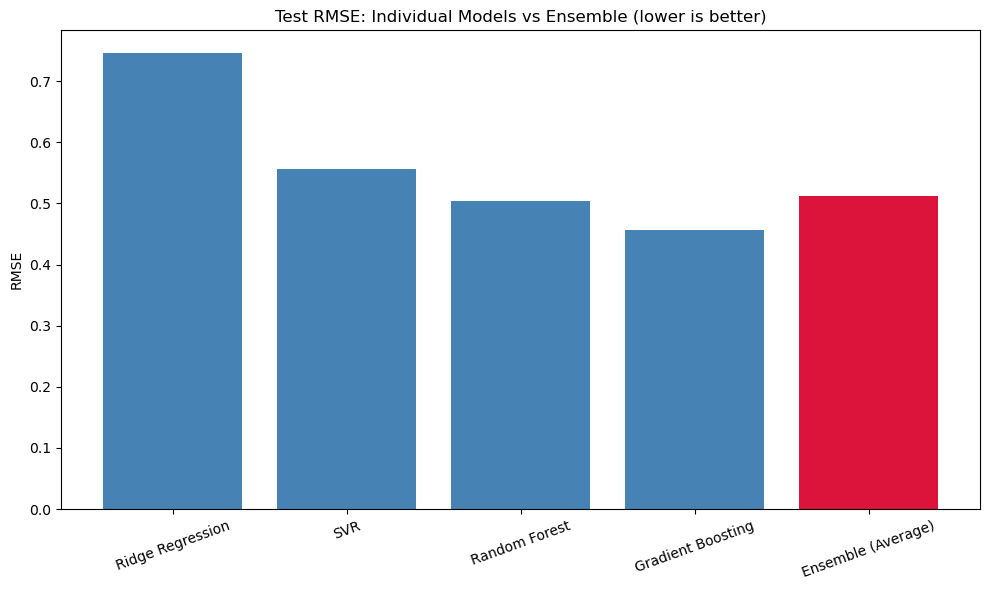

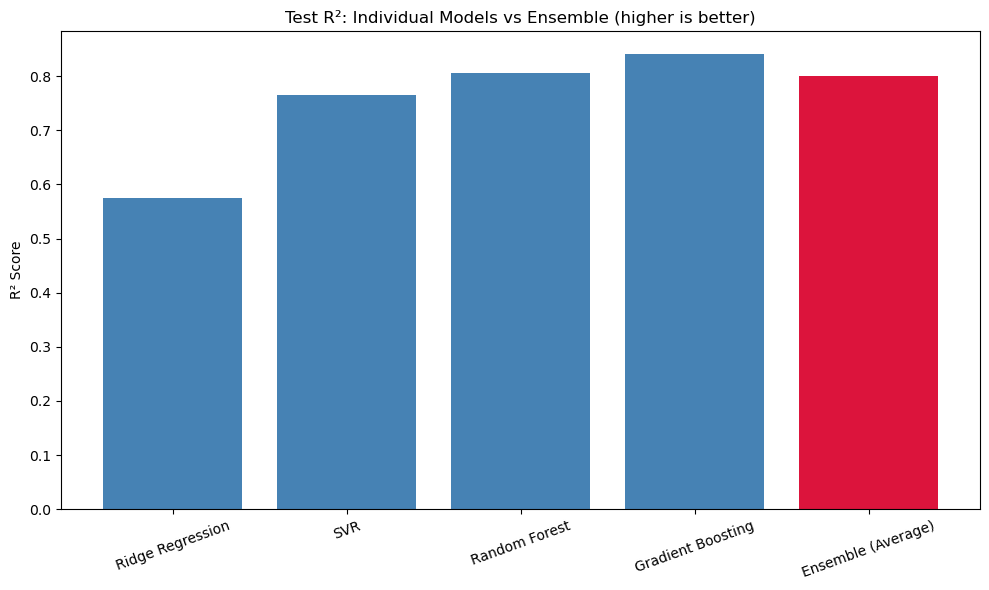

In [89]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophisticated method

# Pick the best-performing tuning method's model for each algorithm
# (based on lowest tuned RMSE from Part 6's full_comparison)
best_models = {}
for model_name in model_names:
    subset = full_comparison[full_comparison['Model'] == model_name]
    best_row = subset.loc[subset['Tuned RMSE'].idxmin()]
    best_method = best_row['Method']
    
    if best_method == 'Grid Search':
        best_models[model_name] = grid_search_results[model_name]['best_model']
    elif best_method == 'Random Search':
        best_models[model_name] = random_search_results[model_name]['best_model']
    else:
        best_models[model_name] = bayes_search_results[model_name]['best_model']
    
    print(f"{model_name}: using {best_method} model (CV RMSE: {best_row['Tuned RMSE']:.4f})")

# Simple averaging ensemble — average predictions across all 4 best tuned models
def ensemble_predict(models_dict, X):
    predictions = np.column_stack([model.predict(X) for model in models_dict.values()])
    return predictions.mean(axis=1)

# TODO: Evaluate the ensemble on the test set
# Compare its performance with individual models

ensemble_test_pred = ensemble_predict(best_models, X_test_scaled)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_test_pred))
ensemble_r2 = r2_score(y_test, ensemble_test_pred)

print(f"\nEnsemble Test RMSE: {ensemble_rmse:.4f}")
print(f"Ensemble Test R²:   {ensemble_r2:.4f}")

# Individual model test performance for comparison
individual_results = []
for model_name, model in best_models.items():
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    individual_results.append({'Model': model_name, 'Test RMSE': rmse, 'Test R²': r2})

individual_results.append({'Model': 'Ensemble (Average)', 'Test RMSE': ensemble_rmse, 'Test R²': ensemble_r2})
final_comparison = pd.DataFrame(individual_results)
print("\nFinal comparison — individual models vs ensemble:")
print(final_comparison.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
colors = ['steelblue'] * len(best_models) + ['crimson']
plt.bar(final_comparison['Model'], final_comparison['Test RMSE'], color=colors)
plt.title('Test RMSE: Individual Models vs Ensemble (lower is better)')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(final_comparison['Model'], final_comparison['Test R²'], color=colors)
plt.title('Test R²: Individual Models vs Ensemble (higher is better)')
plt.ylabel('R² Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [92]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================

# TODO: Summarize your findings
"""
CONCLUSION: Multi-Model Hyperparameter Optimization Challenge

1. BEST MODEL: Gradient Boosting, tuned via Bayesian Optimization
   (CV RMSE: 0.4679, 12.39% improvement over baseline). Confirmed on the
   test set with the lowest RMSE (0.4566) and highest R² (0.8409) overall.
   Random Forest was a distant second (0.37% improvement); Ridge barely
   improved at all (-0.01%), since a linear model can't capture the
   nonlinear structure in housing prices regardless of tuning.

2. MOST EFFICIENT TUNING METHOD: Random Search, especially on Gradient
   Boosting (10.43% improvement in just 47.6s — the highest efficiency
   score of any model/method combo). Grid Search matched Random Search's
   accuracy on Random Forest but took 954s vs. 126s — 7x longer for no real
   gain. Bayesian Optimization was consistently the slowest per iteration
   due to surrogate-model overhead, and with only 20 iterations, it didn't
   clearly outperform Random Search.

3. ENSEMBLE vs INDIVIDUAL: The ensemble (simple averaging) scored worse
   (Test RMSE 0.5126) than Gradient Boosting alone (0.4566). Equal-weighting
   Ridge and SVR (both much weaker) dragged the average down. Naive
   averaging only helps when combined models are of similar quality — that
   wasn't the case here since GB was clearly dominant.

4. KEY LEARNINGS ABOUT HYPERPARAMETER SPACES:
   - Grid Search cost scales multiplicatively with parameter count, not
     additively (Random Forest's 240-combo grid took ~10x longer than
     Gradient Boosting's 36-combo grid).
   - Random Search's fixed 20-iteration budget made it far more efficient
     than Grid Search whenever the grid was large.
   - The meta-learning experiment found Gradient Boosting won 27/30 sampled
     subsets, and a classifier predicting the best algorithm from dataset
     characteristics reached 90% CV accuracy — feature skewness and target
     mean were the most informative signals.
   - Practical note: SVR with a linear kernel caused a severe runtime blowup
     on ~16,500 rows, a reminder that model choice affects tuning time as
     much as the search strategy does.
"""
print("See comments above for full conclusion.")

See comments above for full conclusion.


In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file

In [91]:
import pickle

# Identify the single best model across everything (individual models + ensemble)
final_comparison_sorted = final_comparison.sort_values('Test RMSE')
print(final_comparison_sorted)

best_overall_name = final_comparison_sorted.iloc[0]['Model']
print(f"\nBest overall model: {best_overall_name}")

if best_overall_name == 'Ensemble (Average)':
    # Save the dict of models + a note that predictions are the average
    with open('best_tuned_model.pkl', 'wb') as f:
        pickle.dump(best_models, f)
    print("Saved ensemble (dict of 4 models) to best_tuned_model.pkl")
else:
    with open('best_tuned_model.pkl', 'wb') as f:
        pickle.dump(best_models[best_overall_name], f)
    print(f"Saved {best_overall_name} to best_tuned_model.pkl")

                Model  Test RMSE   Test R²
3   Gradient Boosting   0.456644  0.840871
2       Random Forest   0.503700  0.806386
4  Ensemble (Average)   0.512575  0.799503
1                 SVR   0.555675  0.764367
0    Ridge Regression   0.745579  0.575791

Best overall model: Gradient Boosting
Saved Gradient Boosting to best_tuned_model.pkl
